# Getting Information on the Dataset

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import os

# Auto-detect your project folder—no hardcoding C: or G:
project_root = os.path.dirname(os.path.abspath("__file__"))  # gets notebook's dir
os.chdir(project_root)

print("Switched to:", os.getcwd())
df = pd.read_csv("spacex_web_scraped.csv")
df.head()


Switched to: G:\git\404\sandbox\Curtis Foster\.vscode


,Flight No.,Launch site,Payload,Payload mass,Orbit,Customer,Launch outcome,Date,Time,Version Booster,Booster landing
0,1,Cape Canaveral,Dragon Spacecraft Qualification Unit,U,LEO,SpaceX,Success,4 June 2010,18:45,F9v1.0,Failure (parachute)
1,2,Cape Canaveral,SpaceX COTS Demo Flight 1,U,LEO,NASA,Success,8 December 2010,15:43,F9v1.0,Failure (parachute)
2,3,Cape Canaveral,SpaceX COTS Demo Flight 2,525 kg,LEO,NASA,Success,22 May 2012,07:44,F9 v1.0,No attempt
3,4,Cape Canaveral,SpaceX CRS-1,"4,700 kg",LEO,NASA,Success,8 October 2012,00:35,F9 v1.0,No attempt
4,5,Cape Canaveral,SpaceX CRS-2,"4,877 kg",LEO,NASA,Success,1 March 2013,15:10,F9 v1.0,No attempt


In [4]:
df.tail()

,Flight No.,Launch site,Payload,Payload mass,Orbit,Customer,Launch outcome,Date,Time,Version Booster,Booster landing
516,608,Vandenberg,Starlink,"~14,375 kg",SSO,SpaceX,Success,"March 1, 2026",10:10,F9B5,Success ( OCISLY
517,609,Cape Canaveral,Starlink,"~16,675 kg",LEO,SpaceX,Success,"March 2, 2026",02:56,F9B5,Success ( JRTI
518,610,Cape Canaveral,Starlink,"~16,675 kg",LEO,SpaceX,Success,"March 4, 2026",10:52,F9B5,Success ( ASOG
519,611,Vandenberg,Starlink,"~14,375 kg",SSO,SpaceX,Success,"March 8, 2026",11:00,F9B5,Success ( OCISLY
520,612,Cape Canaveral,EchoStar XXV,"6,800 kg",GTO,EchoStar,Success,"March 10, 2026",04:19,F9B5,Success ( ASOG


### Check For Null Values

In [ ]:
print("Checking for Null Values\n")

print(df.isnull().sum())
# Count how many times each date appears
date_counts = df['Date'].value_counts()

### Check For Duplicates

In [46]:
duplicates = date_counts[date_counts > 1]

print("\nNumber of duplicate dates found:", len(duplicates))
duplicates = date_counts[date_counts > 1]

print("Duplicate dates:")
print(duplicates)



Number of duplicate dates found: 44
Duplicate dates:
Date
December 17, 2024    3
March 4, 2024        3
January 10, 2025     2
July 16, 2025        2
June 23, 2025        2
June 25, 2025        2
June 28, 2025        2
December 17, 2025    2
August 22, 2025      2
October 19, 2025     2
October 15, 2024     2
March 15, 2025       2
August 14, 2025      2
November 14, 2024    2
December 2, 2025     2
February 15, 2024    2
16 December 2022     2
February 11, 2025    2
October 30, 2024     2
November 18, 2024    2
January 29, 2024     2
February 27, 2025    2
November 15, 2025    2
January 3, 2024      2
November 30, 2024    2
February 4, 2025     2
June 13, 2025        2
August 4, 2024       2
May 10, 2025         2
May 28, 2024         2
May 13, 2025         2
April 28, 2025       2
September 3, 2025    2
June 8, 2024         2
January 21, 2025     2
December 29, 2024    2
December 5, 2024     2
July 28, 2024        2
April 28, 2024       2
5 October 2022       2
August 12, 2024      

# Filters

## Flights Per Year

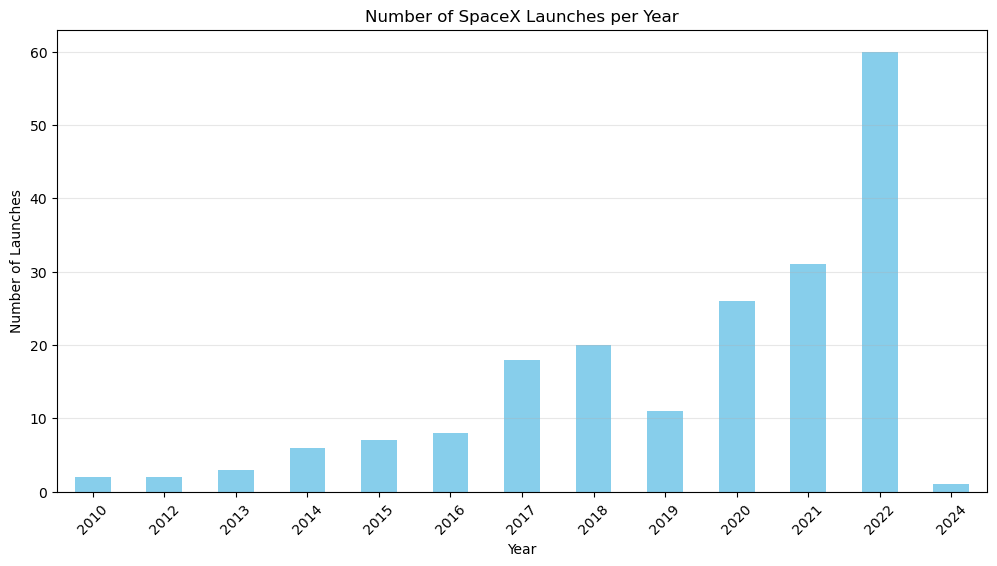

In [42]:
# Make sure Date is datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


# Add Year column if you don't have it yet
df['Year'] = df['Date'].dt.year
df['Year'] = df['Year'].astype('Int64')
# Count launches per year
launches_per_year = df['Year'].value_counts().sort_index()

# Plot the bar chart
plt.figure(figsize=(12, 6))
launches_per_year.plot(kind='bar', color='skyblue')
plt.title('Number of SpaceX Launches per Year')
plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Features

## Renaming Dataset Columns

In [5]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    'Flight No.': 'mission',
    'Launch site': 'site',
    'Payload': 'payload',
    'Payload mass': 'mass',
    'Orbit': 'orbit',
    'Customer': 'cust',
    'Launch outcome':'outcome',
    'Date': 'date',
    'Time': 'time', 
    'Version Booster': 'booster',
    'Booster landing': "reuse"
       
})

print(df.columns.tolist())


['mission', 'site', 'payload', 'mass', 'orbit', 'cust', 'outcome', 'date', 'time', 'booster', 'reuse']


## Gets the Customers and Sorts them

In [6]:
#cleaned for numbers
customerList = df["cust"].dropna().unique()
customerList.sort()




## A Function that creates an dictionary

In [7]:
def create_dict(df, column_name="mission"):
    """
    Takes a DataFrame and a column name, returns a sorted 
    dictionary of unique customers with integer keys.
    """
    # 1. Extract, drop NaNs, and get unique values
    unique_cust = df[column_name].dropna().unique()
    
    # 2. Sort the names alphabetically
    unique_cust.sort()
    
    # 3. Create the dictionary using a comprehension
    # i becomes the key (0, 1, 2...), name becomes the value
    cust_dict = {i: name for i, name in enumerate(unique_cust)}
    
    return cust_dict

# How to use it:
my_cust_data = create_dict(df, "cust")
all_cust_keys = my_cust_data.keys()

df_key = pd.DataFrame(list(my_cust_data.items()), columns=['ID', "Value"])

master_lookup = pd.concat([df_key], axis=0, ignore_index=True)

counter = master_lookup[master_lookup['Value'] == 'SpaceX']

print(counter)



    ID   Value
55  55  SpaceX


## Combined Date and Time

In [ ]:
def get_combined_timestamp_df(df_dates, df_times, date_col='date', time_col='time'):
    # 1. Get the dictionaries
    result_df = pd.DataFrame()

    # 2. Use zip() to pair values safely
    # This stops at the shortest list and doesn't care about keys
    result_df['Timestamp'] = (
        df_dates[date_col].astype(str) + 
        " @ " + 
        df_times[time_col].astype(str)
    )

    # 3. Join with newlines
    return result_df

timestamp = get_combined_timestamp_df(df, df, "date", "time")



print(timestamp.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Timestamp  521 non-null    object
dtypes: object(1)
memory usage: 4.2+ KB
None
